# Fractography

The fractography form records defects found on fracture surfaces of tested specimens. Like the flexural form, each entry holds a list of `tests` — here each element is one measured defect, with its morphology and its position on the fracture surface.

This notebook:

1. Explodes the defect measurements into a tidy frame
2. Normalizes the inconsistent surface/subsurface labelling
3. Characterizes defect size, shape and type
4. Relates defect size to position on the fracture surface

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "imqcam.py").exists())
sys.path.insert(0, str(REPO_ROOT))

from imqcam import entries_to_frame, explode_records, fetch_entries, get_client

BLUE, ORANGE, GREEN, PURPLE = "#4C8BE2", "#E26C4C", "#4CE2A7", "#9B7CE2"
FRACTOGRAPHY = "69fa1d0872a32de5fe95028b"

client = get_client()
entries = fetch_entries(client, form_id=FRACTOGRAPHY, page_size=100)

print(f"{len(entries)} fractography records")

72 fractography records


## Defect level

One row per measured defect, carrying the specimen IGSN and build id down from the parent record.

In [2]:
defects = explode_records(entries, "tests")

print(f"{len(defects)} defects across {defects['uniqueId'].nunique()} specimens")
print(f"Defects per specimen: "
      f"{defects.groupby('uniqueId').size().value_counts().sort_index().to_dict()}")
defects.head()

148 defects across 72 specimens
Defects per specimen: {1: 22, 2: 31, 3: 13, 4: 5, 5: 1}


,_id,uniqueId,formId,igsn,recordIndex,Defect_Type,Fatigue_Tensile,Initiated_at_Chamfer,Retest,Surface_Subsurface,...,feretAngle,feretX,feretY,minFeret,perimeter,rootArea,roundness,testNumber,x,y
0,69fbc81ec9ffe295ae6b1133,CMXMAL00011-01,69fa1d0872a32de5fe95028b,CMXMAL00011-01,0,Keyhole,,No,0,Surface,...,136.703,555.0,248.0,22.318,84.103,21.236313,0.780,1,41.220,24.777
1,69fbc81ec9ffe295ae6b1133,CMXMAL00011-01,69fa1d0872a32de5fe95028b,CMXMAL00011-01,1,Keyhole,,No,0,subsurface,...,168.024,737.0,485.0,33.162,109.772,30.448941,0.929,2,415.302,268.584
2,69fbc81fc9ffe295ae6b1135,CMXMAL00011-03,69fa1d0872a32de5fe95028b,CMXMAL00011-03,0,Gas_Pore,,No,0,subsurface,...,160.974,743.0,499.0,7.367,24.570,6.794042,0.898,1,104.669,68.607
3,69fbc81fc9ffe295ae6b1135,CMXMAL00011-03,69fa1d0872a32de5fe95028b,CMXMAL00011-03,1,Gas_Pore,,Yes,0,subsurface,...,112.751,744.0,485.0,4.113,13.720,3.760585,0.971,2,102.205,68.320
4,69fbc81fc9ffe295ae6b1135,CMXMAL00011-03,69fa1d0872a32de5fe95028b,CMXMAL00011-03,2,Gas_Pore,,Yes,1,subsurface,...,112.751,744.0,485.0,4.113,13.720,3.760585,0.971,2,102.205,68.320


### Data overview

Each row is one defect measured on a fracture surface. The morphology fields are standard image-analysis descriptors, in micrometres and µm² unless noted.

- **`Defect_Type`** — the defect mechanism, e.g. keyhole or lack of fusion
- **`Surface_Subsurface`** — whether the defect broke the surface
- **`area`** — projected defect area (µm²)
- **`rootArea`** — √area, the length scale used in Murakami-style fatigue models (µm)
- **`equidiameter`** — diameter of a circle of equal area (µm)
- **`feret`, `minFeret`, `feretAngle`** — maximum and minimum calliper diameters and orientation
- **`perimeter`** — defect perimeter (µm)
- **`circ`, `roundness`, `aspRatio`, `convexity`** — dimensionless shape descriptors
- **`x`, `y`, `feretX`, `feretY`** — position on the fracture surface
- **`Initiated_at_Chamfer`** — whether failure initiated at a specimen edge

In [3]:
numeric = ["area", "rootArea", "equidiameter", "feret", "minFeret", "feretAngle",
           "perimeter", "circ", "roundness", "aspRatio", "convexity", "x", "y"]
for column in numeric:
    if column in defects.columns:
        defects[column] = pd.to_numeric(defects[column], errors="coerce")

defects[["area", "rootArea", "equidiameter", "feret", "circ", "roundness"]].describe().round(2)

,area,rootArea,equidiameter,feret,circ,roundness
count,148.00,148.00,148.00,148.00,148.00,148.00
mean,1573.92,35.00,39.50,59.50,0.70,0.63
std,1634.75,18.74,21.14,38.20,0.22,0.22
min,14.14,3.76,4.24,4.57,0.21,0.13
25%,473.99,21.77,24.56,33.16,0.53,0.44
50%,953.34,30.87,34.84,51.45,0.71,0.66
75%,2386.26,48.85,55.12,77.16,0.90,0.81
max,8834.33,93.99,106.06,193.36,0.98,0.97


## Categorical labels are inconsistently cased

`Surface_Subsurface` records one class capitalized and the other not — `Surface` against `subsurface`. No class is currently split in two, so the counts are unaffected, but the inconsistency is one entry away from becoming a real problem: a single `Subsurface` would silently create a third group.

Normalizing to lowercase costs nothing and makes the column safe to group on.

In [4]:
print("As recorded:")
print(defects["Surface_Subsurface"].value_counts(dropna=False).to_string())

defects["surfaceClass"] = (
    defects["Surface_Subsurface"].fillna("").str.strip().str.lower().replace({"": None})
)

print("\nNormalized:")
print(defects["surfaceClass"].value_counts(dropna=False).to_string())

As recorded:
Surface_Subsurface
Surface       111
subsurface     37

Normalized:
surfaceClass
surface       111
subsurface     37


## Defect types

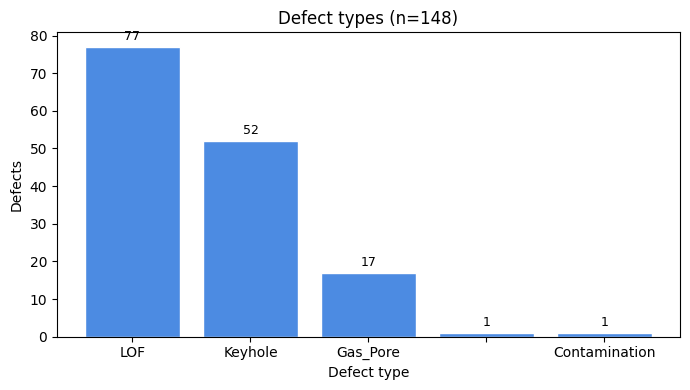

In [5]:
type_counts = defects["Defect_Type"].fillna("(unrecorded)").value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(type_counts.index, type_counts.values, color=BLUE, edgecolor="white")
for bar, value in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{value:,}",
            ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Defect type")
ax.set_ylabel("Defects")
ax.set_title(f"Defect types (n={len(defects):,})")
plt.tight_layout()
plt.show()

## Defect size distribution

`rootArea` (√area) is the size measure that matters for fatigue: Murakami's model predicts fatigue strength scales with it rather than with area directly. Plotted alongside area to show why the square-root scale is the more readable one.

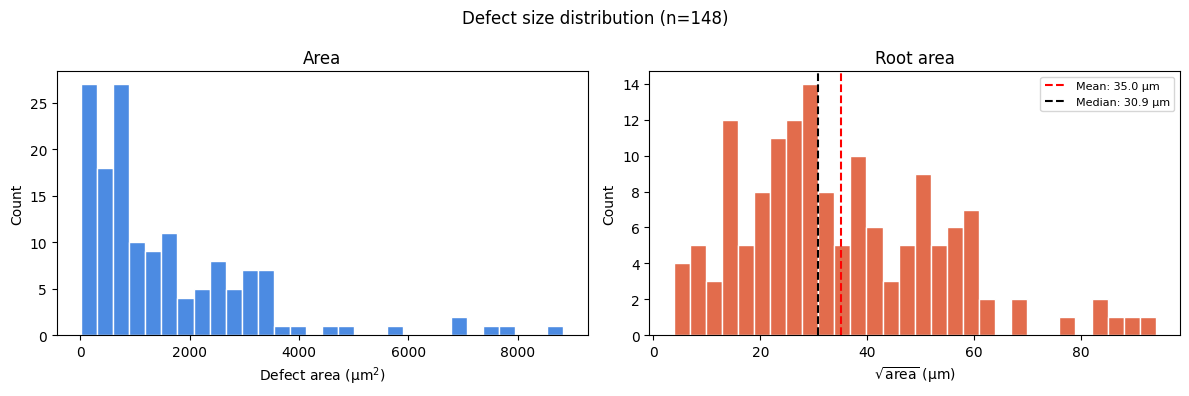

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(defects["area"].dropna(), bins=30, color=BLUE, edgecolor="white")
axes[0].set_xlabel("Defect area (µm$^2$)")
axes[0].set_ylabel("Count")
axes[0].set_title("Area")

root_area = defects["rootArea"].dropna()
axes[1].hist(root_area, bins=30, color=ORANGE, edgecolor="white")
axes[1].axvline(root_area.mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"Mean: {root_area.mean():.1f} µm")
axes[1].axvline(root_area.median(), color="black", linestyle="--", linewidth=1.5,
                label=f"Median: {root_area.median():.1f} µm")
axes[1].set_xlabel(r"$\sqrt{\mathrm{area}}$ (µm)")
axes[1].set_ylabel("Count")
axes[1].set_title("Root area")
axes[1].legend(fontsize=8)

fig.suptitle(f"Defect size distribution (n={len(root_area):,})")
plt.tight_layout()
plt.show()

## Size by surface class

Surface-breaking defects are more damaging than internal ones at equal size, so the two populations are worth separating before any size distribution is fitted.

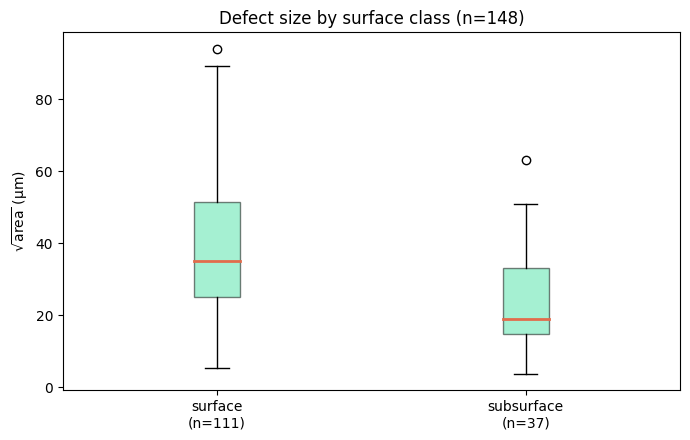

In [7]:
classes = [c for c in defects["surfaceClass"].dropna().unique()]
by_class = defects.dropna(subset=["surfaceClass", "rootArea"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot(
    [by_class.loc[by_class["surfaceClass"] == c, "rootArea"] for c in classes],
    labels=[f"{c}\n(n={(by_class['surfaceClass'] == c).sum()})" for c in classes],
    patch_artist=True,
    boxprops=dict(facecolor=GREEN, alpha=0.5),
    medianprops=dict(color=ORANGE, linewidth=2),
)
ax.set_ylabel(r"$\sqrt{\mathrm{area}}$ (µm)")
ax.set_title(f"Defect size by surface class (n={len(by_class):,})")
plt.tight_layout()
plt.show()

## Shape versus size

Circularity against size shows whether large defects are also more irregular — the signature of lack-of-fusion defects, which are flat and jagged, against keyhole porosity, which is round.

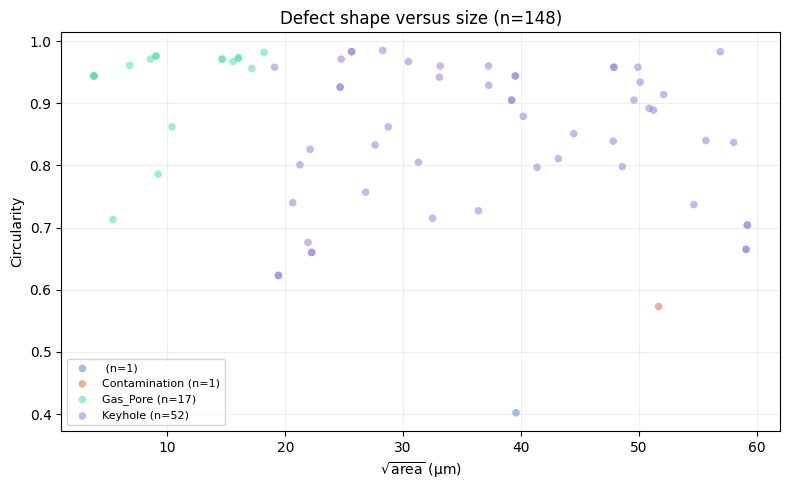

In [8]:
shape_data = defects.dropna(subset=["rootArea", "circ"])

fig, ax = plt.subplots(figsize=(8, 5))
for defect_type, colour in zip(sorted(shape_data["Defect_Type"].fillna("(unrecorded)").unique()),
                              (BLUE, ORANGE, GREEN, PURPLE)):
    subset = shape_data[shape_data["Defect_Type"].fillna("(unrecorded)") == defect_type]
    ax.scatter(subset["rootArea"], subset["circ"], s=30, alpha=0.55, color=colour,
               label=f"{defect_type} (n={len(subset)})", edgecolors="none")

ax.set_xlabel(r"$\sqrt{\mathrm{area}}$ (µm)")
ax.set_ylabel("Circularity")
ax.set_title(f"Defect shape versus size (n={len(shape_data):,})")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Position on the fracture surface

`x` and `y` locate each defect on the fracture face. Marker size scales with defect size, so initiation-scale defects stand out.

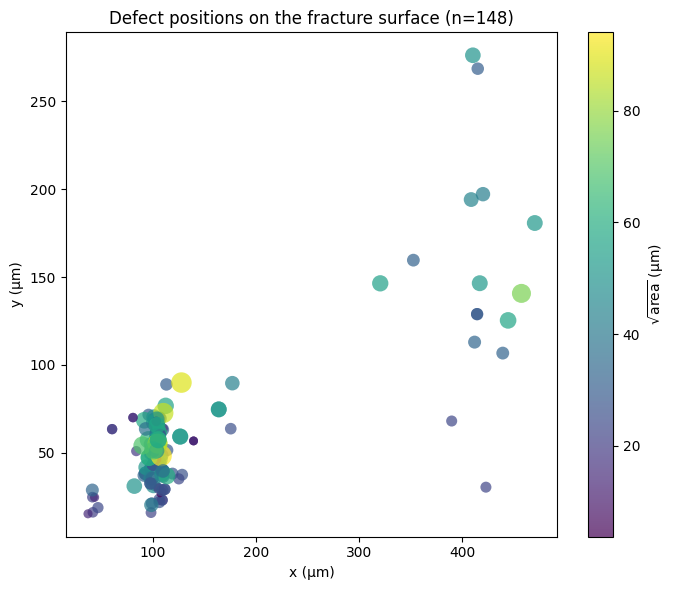

In [9]:
positions = defects.dropna(subset=["x", "y", "rootArea"])

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(positions["x"], positions["y"],
                     s=positions["rootArea"] / positions["rootArea"].max() * 220 + 10,
                     c=positions["rootArea"], cmap="viridis", alpha=0.7, edgecolors="none")
fig.colorbar(scatter, ax=ax, label=r"$\sqrt{\mathrm{area}}$ (µm)")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title(f"Defect positions on the fracture surface (n={len(positions):,})")
plt.tight_layout()
plt.show()

## Largest defect per specimen

Fatigue life is governed by the single most severe defect, not by the average one. For any model relating defect population to life, the per-specimen maximum is the feature to carry forward.

In [10]:
worst = (
    defects.dropna(subset=["rootArea"])
    .sort_values("rootArea", ascending=False)
    .groupby("uniqueId")
    .first()
    .reset_index()
)

print(f"{len(worst)} specimens with at least one measured defect")
print(f"Largest defect per specimen: median {worst['rootArea'].median():.1f} µm, "
      f"max {worst['rootArea'].max():.1f} µm")

worst[["uniqueId", "igsn", "Defect_Type", "surfaceClass", "rootArea", "circ"]].head(10)

72 specimens with at least one measured defect
Largest defect per specimen: median 40.4 µm, max 94.0 µm


,uniqueId,igsn,Defect_Type,surfaceClass,rootArea,circ
0,CMXMAL00011-01,CMXMAL00011-01,Keyhole,subsurface,30.448941,0.967
1,CMXMAL00011-03,CMXMAL00011-03,Gas_Pore,subsurface,6.794042,0.961
2,CMXMAL00011-05,CMXMAL00011-05,Keyhole,surface,39.522753,0.944
3,CMXMAL00011-06,CMXMAL00011-06,Keyhole,surface,22.238323,0.660
4,CMXMAL00011-08,CMXMAL00011-08,Keyhole,surface,56.921499,0.983
5,CMXMAL00011-10,CMXMAL00011-10,Keyhole,subsurface,28.263970,0.985
6,CMXMAL00011-12,CMXMAL00011-12,Keyhole,surface,39.208621,0.905
7,CMXMAL00011-13,CMXMAL00011-13,Keyhole,surface,32.498585,0.715
8,CMXMAL00011-19,CMXMAL00011-19,Keyhole,surface,33.081203,0.942
9,CMXMAL00011-22,CMXMAL00011-22,Keyhole,surface,51.255253,0.889
